# PINN for an Inverse Problem: Beam Deflection

## 1. Setup and Imports

In [7]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Problem Definition and Synthetic Data Generation

In [8]:
# Known Parameters
E = 210e9  # Young's Modulus for steel (Pa)
I = 3.255e-6 # Moment of inertia for a sample beam (m^4)
L = 5.0    # Length of the beam (m)
EI = E * I

q_true = -15000.0 # The actual uniform load (N/m)

# Analytical solution function 
def analytical_solution(x, q, E, I, L):
    return (q * x / (24 * E * I)) * (L**3 - 2 * L * x**2 + x**3)

# Sensor Data Generation
n_sensors = 7
x_sensor = torch.linspace(0, L, n_sensors + 2)[1:-1].view(-1, 1).to(device) # Exclude supports
u_sensor = analytical_solution(x_sensor.cpu().numpy(), q_true, E, I, L)
u_sensor = torch.from_numpy(u_sensor).float().to(device)

## The Neural Network and Learnable Parameters

In [9]:
class PINN(nn.Module):
    def __init__(self, L, hidden_size=64):
        super(PINN, self).__init__()
        self.L = L
        self.net = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )
        # Initialize weights
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return x * (self.L - x) * self.net(x)

model = PINN(L).to(device)

# Define the unknown load as a learnable parameter, starting with an initial guess
q_param = nn.Parameter(torch.tensor([-5000.0], device=device))

## The Modified Loss Function

In [10]:
def physics_informed_loss(model, q_param, x_collocation, x_boundary, x_sensor, u_sensor, EI):
    # Data loss 
    u_pred_sensor = model(x_sensor)
    loss_data = torch.mean((u_pred_sensor - u_sensor)**2)

    # Moment boundary condition loss
    u_b = model(x_boundary)
    du_dx_b = torch.autograd.grad(u_b, x_boundary, grad_outputs=torch.ones_like(u_b), create_graph=True)[0]
    d2u_dx2_b = torch.autograd.grad(du_dx_b, x_boundary, grad_outputs=torch.ones_like(du_dx_b), create_graph=True)[0]
    loss_bc = torch.mean((d2u_dx2_b)**2)
    
    # Physics loss 
    u = model(x_collocation)
    du_dx = torch.autograd.grad(u, x_collocation, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    d2u_dx2 = torch.autograd.grad(du_dx, x_collocation, grad_outputs=torch.ones_like(du_dx), create_graph=True)[0]
    d3u_dx3 = torch.autograd.grad(d2u_dx2, x_collocation, grad_outputs=torch.ones_like(d2u_dx2), create_graph=True)[0]
    d4u_dx4 = torch.autograd.grad(d3u_dx3, x_collocation, grad_outputs=torch.ones_like(d3u_dx3), create_graph=True)[0]
    
    residual = EI * d4u_dx4 - q_param
    loss_physics = torch.mean(residual**2)
    
    return loss_data, loss_bc, loss_physics

## 5. Model Training

In [11]:
optimizer = torch.optim.Adam(list(model.parameters()) + [q_param], lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3000, gamma=0.5)

n_epochs = 50000
n_collocation = 800

# Boundary points
x_boundary = torch.tensor([0.0, L]).float().view(-1, 1).to(device).requires_grad_(True)

q_history = []
loss_history = {'total': [], 'data': [], 'boundary': [], 'physics': []}

model.train()
lambda_bc = 1.0

for epoch in range(n_epochs):
    optimizer.zero_grad()
    
    x_collocation = (torch.rand(n_collocation, 1, requires_grad=True) * L).to(device)

    loss_data, loss_bc, loss_physics = physics_informed_loss(
        model, q_param, x_collocation, x_boundary, x_sensor, u_sensor, EI
    )

    if epoch < 5000:
        # Phase 1: Focus heavily on fitting the sensor data to learn the shape
        lambda_data = 1000.0
        lambda_physics = 0.1
    elif epoch < 15000:
        # Phase 2: Balance fitting the data with obeying the physics
        lambda_data = 100.0
        lambda_physics = 1.0
    else:
        # Phase 3: Focus on physics to fine-tune the parameter q
        lambda_data = 1.0
        lambda_physics = 1000



    total_loss = lambda_data * loss_data + lambda_bc * loss_bc + lambda_physics * loss_physics
    
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(list(model.parameters()) + [q_param], max_norm=1.0)
    
    optimizer.step()
    scheduler.step()

    q_history.append(q_param.item())
    loss_history['total'].append(total_loss.item())
    loss_history['data'].append(loss_data.item())
    loss_history['boundary'].append(loss_bc.item())
    loss_history['physics'].append(loss_physics.item())

    if (epoch + 1) % 2000 == 0:
        print(f'Epoch [{epoch+1:5d}/{n_epochs}] | '
              f'Total: {total_loss.item():.2e} | '
              f'Data: {loss_data.item():.2e} | '
              f'q: {q_param.item():.2f}')
        
print("Training completed!")
print(f"\nTrue load: {q_true:.2f} N/m")
print(f"Learned load: {q_param.item():.2f} N/m")
final_error_pct = abs(q_param.item() - q_true) / abs(q_true) * 100
print(f"Error: {abs(q_param.item() - q_true):.2f} N/m ({final_error_pct:.2f}%)")

Epoch [ 2000/50000] | Total: 2.12e+05 | Data: 1.85e-03 | q: -5000.00
Epoch [ 4000/50000] | Total: 2.46e+03 | Data: 1.13e-04 | q: -4999.99
Epoch [ 6000/50000] | Total: 6.09e+03 | Data: 2.35e-04 | q: -4999.99
Epoch [ 8000/50000] | Total: 1.19e+03 | Data: 6.97e-05 | q: -4999.99
Epoch [10000/50000] | Total: 3.06e+03 | Data: 4.59e-05 | q: -4999.99
Epoch [12000/50000] | Total: 2.18e+03 | Data: 6.74e-05 | q: -4999.99
Epoch [14000/50000] | Total: 3.65e+02 | Data: 4.84e-05 | q: -4999.99
Epoch [16000/50000] | Total: 3.44e+04 | Data: 7.09e-05 | q: -4999.99
Epoch [18000/50000] | Total: 4.22e+04 | Data: 1.56e-04 | q: -4999.99
Epoch [20000/50000] | Total: 9.18e+03 | Data: 3.02e-04 | q: -4999.99
Epoch [22000/50000] | Total: 3.32e+03 | Data: 3.13e-04 | q: -4999.99
Epoch [24000/50000] | Total: 2.83e+03 | Data: 2.69e-04 | q: -4999.99
Epoch [26000/50000] | Total: 7.18e+02 | Data: 2.04e-04 | q: -4999.99
Epoch [28000/50000] | Total: 2.80e+02 | Data: 1.57e-04 | q: -4999.99
Epoch [30000/50000] | Total: 2.81e

## 6. Results and Visualization

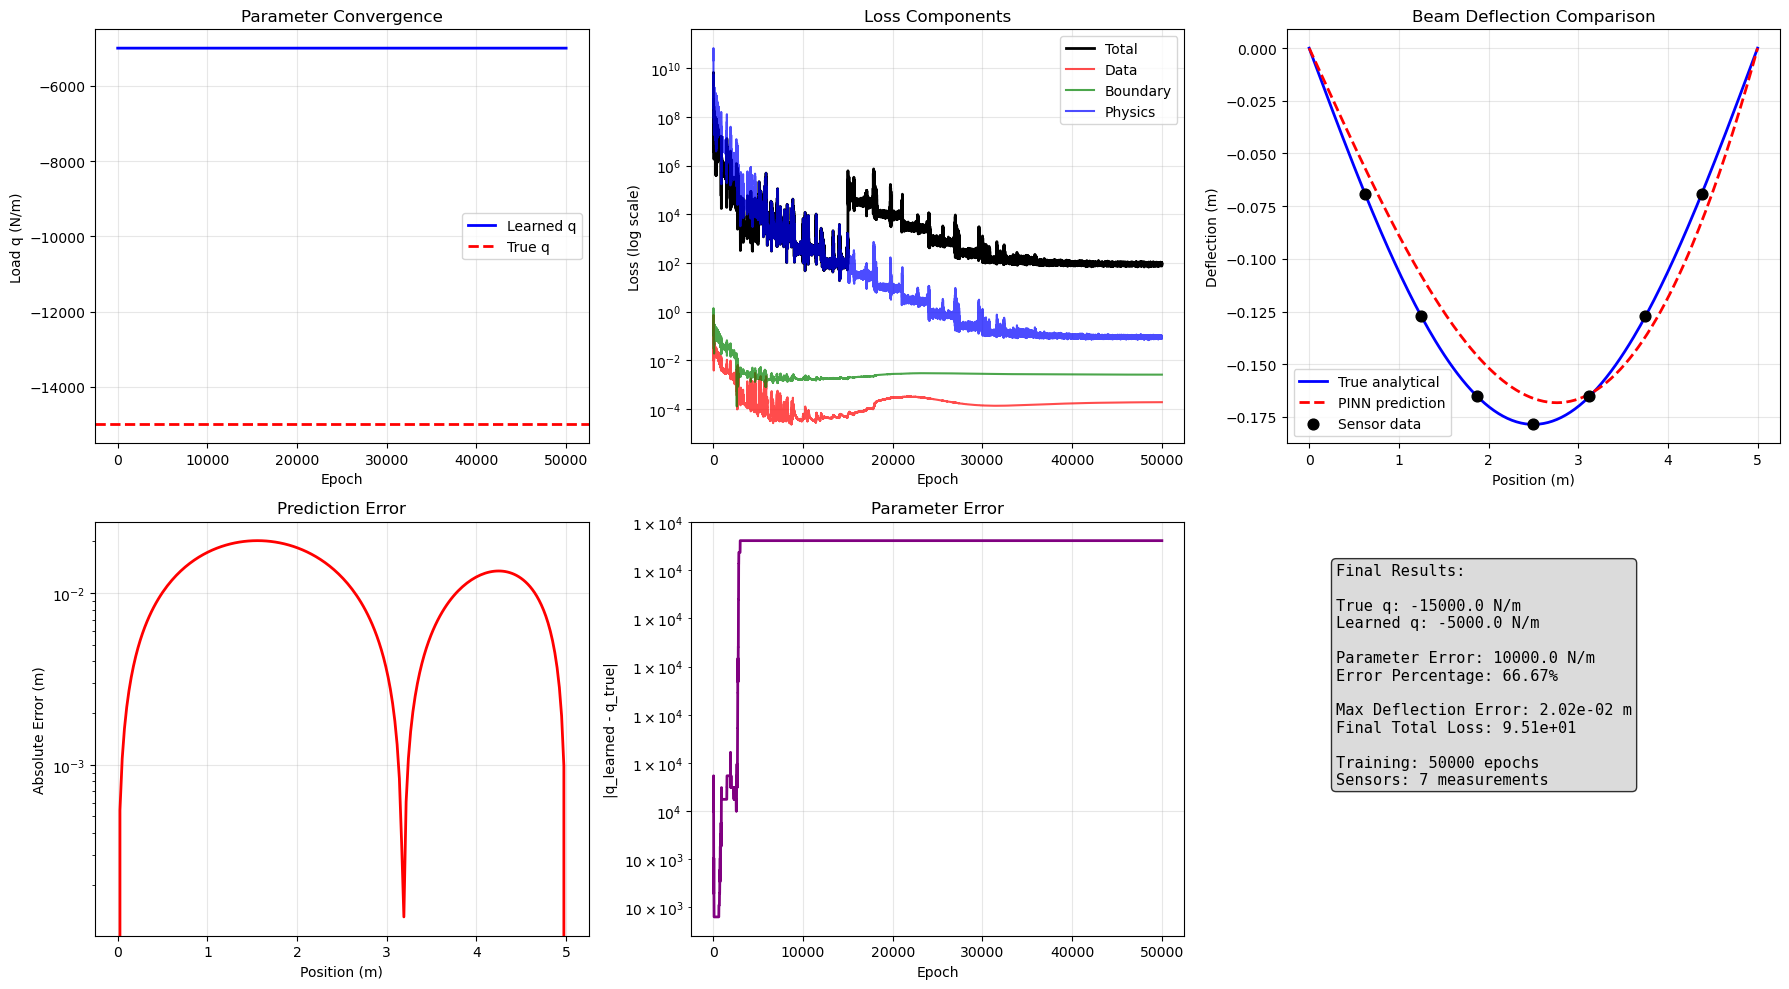

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Parameter convergence
axes[0,0].plot(q_history, 'b-', linewidth=2, label='Learned q')
axes[0,0].axhline(y=q_true, color='r', linestyle='--', linewidth=2, label='True q')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Load q (N/m)')
axes[0,0].set_title('Parameter Convergence')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)


# Plot 2: Loss components
epochs = range(len(loss_history['total']))
axes[0,1].semilogy(epochs, loss_history['total'], 'k-', linewidth=2, label='Total')
axes[0,1].semilogy(epochs, loss_history['data'], 'r-', alpha=0.7, label='Data')
axes[0,1].semilogy(epochs, loss_history['boundary'], 'g-', alpha=0.7, label='Boundary')
axes[0,1].semilogy(epochs, loss_history['physics'], 'b-', alpha=0.7, label='Physics')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss (log scale)')
axes[0,1].set_title('Loss Components')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)


# Plot 3: Solution comparison
model.eval()
x_test = torch.linspace(0, L, 200).view(-1, 1).to(device)
with torch.no_grad():
    u_pred = model(x_test).cpu().numpy().flatten()

x_analytical = np.linspace(0, L, 200)
u_analytical = analytical_solution(x_analytical, q_true, E, I, L)

axes[0,2].plot(x_analytical, u_analytical, 'b-', linewidth=2, label='True analytical')
axes[0,2].plot(x_test.cpu().numpy(), u_pred, 'r--', linewidth=2, label='PINN prediction')
axes[0,2].scatter(x_sensor.cpu().numpy(), u_sensor.cpu().numpy(), 
                 color='black', s=60, zorder=5, label='Sensor data')
axes[0,2].set_xlabel('Position (m)')
axes[0,2].set_ylabel('Deflection (m)')
axes[0,2].set_title('Beam Deflection Comparison')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# Plot 4: Error distribution
error = np.abs(u_pred - u_analytical)
axes[1,0].plot(x_test.cpu().numpy(), error, 'r-', linewidth=2)
axes[1,0].set_xlabel('Position (m)')
axes[1,0].set_ylabel('Absolute Error (m)')
axes[1,0].set_title('Prediction Error')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_yscale('log')

# Plot 5: Parameter error over time
q_error = [abs(q - q_true) for q in q_history]
axes[1,1].semilogy(epochs, q_error, 'purple', linewidth=2)
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('|q_learned - q_true|')
axes[1,1].set_title('Parameter Error')
axes[1,1].grid(True, alpha=0.3)

# Plot 6: Final statistics
axes[1,2].axis('off')
final_error = abs(q_param.item() - q_true)
final_error_pct = (final_error / abs(q_true)) * 100
max_deflection_error = np.max(error)

stats_text = f"""Final Results:

True q: {q_true:.1f} N/m
Learned q: {q_param.item():.1f} N/m

Parameter Error: {final_error:.1f} N/m
Error Percentage: {final_error_pct:.2f}%

Max Deflection Error: {max_deflection_error:.2e} m
Final Total Loss: {loss_history['total'][-1]:.2e}

Training: {n_epochs} epochs
Sensors: {n_sensors} measurements"""

axes[1,2].text(0.1, 0.9, stats_text, transform=axes[1,2].transAxes, 
               fontsize=11, verticalalignment='top', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()